# PROCESAMIENTO DEL HABLA
## Laboratorio Nº 2
## "PREPARACIÓN DE DEATO CRUDOS EN PYTHON"

In [ ]:
# 📥 Instalación de dependencias (ejecutar una vez)
!pip install librosa numpy matplotlib scipy ipywidgets
# 📚 Importación de módulos
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from scipy import signal
from IPython.display import Audio, display
import ipywidgets as widgets
from ipywidgets import interact
# ⚙️ Configuración de visualización
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['font.size'] = 11
plt.style.use('seaborn-v0_8-whitegrid')
print("✅ Entorno listo. ¡Comencemos!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.2 MB/s eta 0:00:00
✅ Entorno listo. ¡Comencemos!


## Parte 1: Generación de Audio Sintético (Para Práctica)

In [ ]:
def generar_audio_prueba(frecuencias, duracion=3.0, sr=22050, ruido=0.02):
    """
    Genera una señal de audio sintética para prácticas.
    Parámetros:
    - frecuencias: lista de frecuencias en Hz (ej. [200, 400])
    - duracion: duración en segundos
    - sr: sample rate
    - ruido: nivel de ruido blanco añadido (0.0 = limpio)
    """
    t = np.linspace(0, duracion, int(sr * duracion), endpoint=False)
    señal = np.zeros_like(t)
    # Sumar ondas senoidales
    for f in frecuencias: señal += np.sin(2 * np.pi * f * t)
    # Normalizar a [-0.8, +0.8] para dejar margen
    señal = 0.8 * señal / np.max(np.abs(señal))
    # Añadir ruido blanco opcional
    if ruido > 0: señal += ruido * np.random.randn(len(señal))
    señal = np.clip(señal, -1, 1) # Evitar saturación
    return señal, sr
# 🎵 Crear 3 ejemplos para el laboratorio
audio_limpio, sr = generar_audio_prueba([300], ruido=0.0)
audio_ruidoso, _ = generar_audio_prueba([300], ruido=0.05)
audio_largo, _ = generar_audio_prueba([200, 500], duracion=8.0, ruido=0.01)

print (f"✅ Generados: limpio ({len(audio_limpio)/sr:.1f}s), ruidoso, largo ({len(audio_largo)/sr:.1f}s)")

✅ Generados: limpio (3.0s), ruidoso, largo (8.0s)


## Parte 2: Carga y Diagnóstico Visual

📋 Audio limpio:


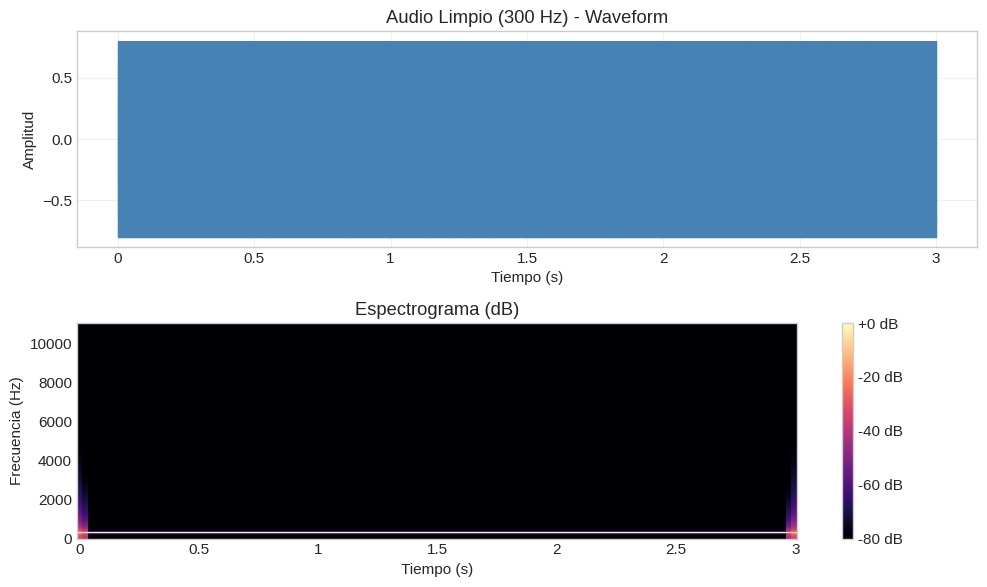

📏 Duración: 3.00 s
🔊 Amplitud: [-0.800, 0.800]
⚡ Energía RMS: 0.5657
🔄 Zero-Crossing Rate medio: 0.0269

📋 Audio ruidoso:


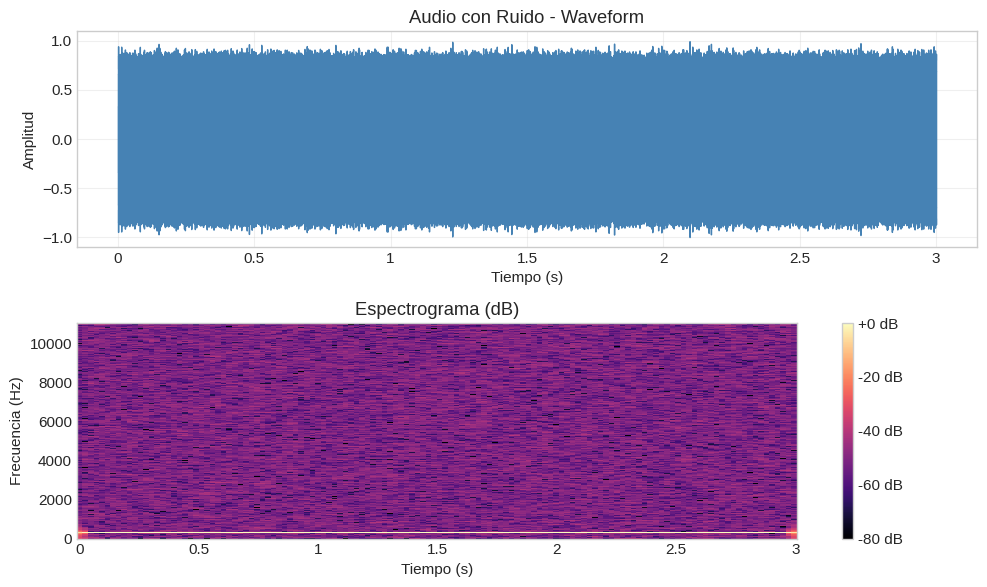

📏 Duración: 3.00 s
🔊 Amplitud: [-0.996, 0.968]
⚡ Energía RMS: 0.5677
🔄 Zero-Crossing Rate medio: 0.0318


In [ ]:
def diagnosticar_audio (audio, sr, titulo ="Diagnóstico"):
    """Muestra waveform y espectrograma básico para evaluación visual"""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
    #Waveform

    librosa.display.waveshow(audio, sr=sr, ax=ax1, color='steelblue')
    ax1.set_title(f'{titulo} - Waveform')
    ax1.set_xlabel('Tiempo (s)')
    ax1.set_ylabel('Amplitud')
    ax1.grid(True, alpha=0.3)
    # Espectrograma (STFT básica)
    D = np.abs(librosa.stft(audio))
    S_db = librosa.amplitude_to_db(D, ref=np.max)
    img = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz', ax=ax2,
    cmap='magma')
    ax2.set_title('Espectrograma (dB)')
    ax2.set_xlabel('Tiempo (s)')
    ax2.set_ylabel('Frecuencia (Hz)')
    plt.colorbar(img, ax=ax2, format='%+2.0f dB')
    plt.tight_layout()
    plt.show()
    # Métricas rápidas
    print(f"📏 Duración: {len(audio)/sr:.2f} s")
    print(f"🔊 Amplitud: [{audio.min():.3f}, {audio.max():.3f}]")
    print(f"⚡ Energía RMS: {np.sqrt(np.mean(audio**2)):.4f}")
    print(f"🔄 Zero-Crossing Rate medio: {librosa.feature.zero_crossing_rate(audio).mean():.4f}")
# 🔍 Diagnosticar los audios de prueba
print("📋 Audio limpio:")
diagnosticar_audio(audio_limpio, sr, "Audio Limpio (300 Hz)")
print("\n📋 Audio ruidoso:")
diagnosticar_audio(audio_ruidoso, sr, "Audio con Ruido")

## Parte 3: Limpieza Interactiva (Trimming y Suavizado)

In [ ]:
def aplicar_limpieza(audio, sr, top_db, clip_limit=0.95):
    """Aplica trimming y clipping suave, muestra comparación"""
    # 1. Recortar silencios
    audio_trim, _ = librosa.effects.trim(audio, top_db=top_db)
    # 2. Suavizar picos extremos (evitar saturación digital)
    audio_clean = np.clip(audio_trim, -clip_limit, clip_limit)
    # Comparación visual
    plt.figure(figsize=(10, 5))
    plt.subplot(2, 1, 1)
    librosa.display.waveshow(audio, sr=sr, label='Original', alpha=0.6)
    plt.title(f'Antes de limpieza (top_db={top_db} dB)')
    plt.ylabel('Amplitud')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.subplot(2, 1, 2)
    librosa.display.waveshow(audio_clean, sr=sr, color='green', label='Limpio')
    plt.title('Después de trimming + clipping suave')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    # Resumen
    reduccion = (1 - len(audio_clean)/len(audio)) * 100
    print(f"✅ Silencios recortados: {reduccion:.1f}% del audio original")
    print(f"✅ Amplitud acotada a [-{clip_limit}, +{clip_limit}]")
    return audio_clean
# 🎛️ Control interactivo para experimentar con top_db
print("🎛️ Ajusta el umbral de trimming (10-60 dB) y observa el efecto:")
interact(
lambda db: aplicar_limpieza(audio_ruidoso, sr, db), db=widgets.IntSlider(min=10, max=60, step=5, value=30, description='top_db (dB):'));

🎛️ Ajusta el umbral de trimming (10-60 dB) y observa el efecto:


interactive(children=(IntSlider(value=30, description='top_db (dB):', max=60, min=10, step=5), Output()), _dom…

## Parte 4: Normalización Completa (Pipeline)

🚀 Aplicando pipeline de normalización al audio de 8s...
✅ Amplitud normalizada a [-1, +1]
✂️ Recortado a 3.0s (centrado)


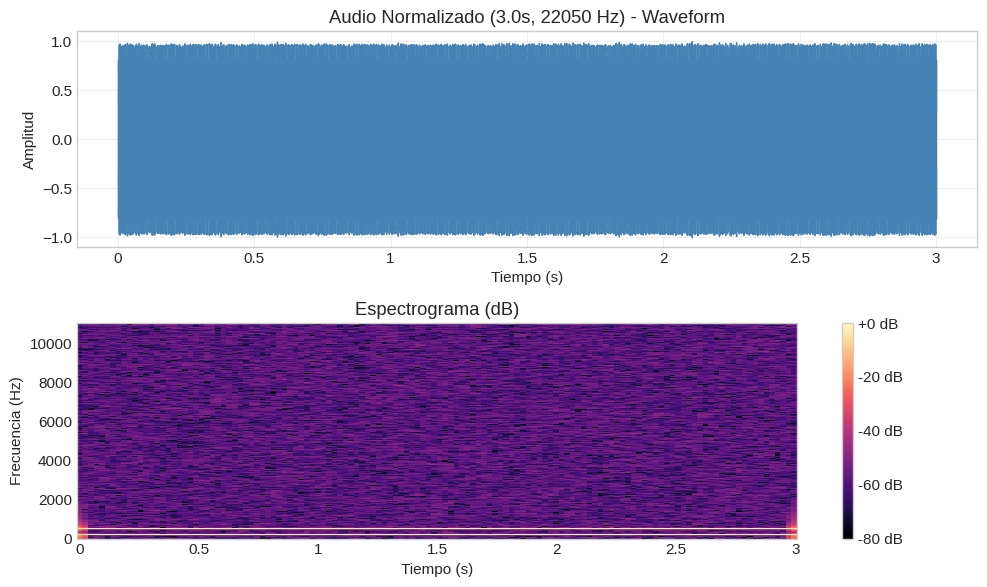

📏 Duración: 3.00 s
🔊 Amplitud: [-1.000, 0.992]
⚡ Energía RMS: 0.4902
🔄 Zero-Crossing Rate medio: 0.0470

🔊 Reproduciendo audio normalizado...


In [ ]:
def pipeline_normalizacion(audio, sr, target_sr=22050, target_dur=3.0,
                           normalize_peak=True):
    """
    Pipeline completo de normalización:
    1. Mono (si es estéreo)
    2. Remuestreo
    3. Normalización de amplitud
    4. Ajuste de duración
    """
    # Paso 1: Asegurar mono
    if audio.ndim == 2:
        audio = librosa.to_mono(audio)
        print("🔄 Convertido a mono")
    # Paso 2: Remuestrear si es necesario
    if sr != target_sr:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=target_sr)
        sr = target_sr
        print(f"🔄 Remuestreado a {target_sr} Hz")
    # Paso 3: Normalizar amplitud (peak normalization)
    if normalize_peak and np.max(np.abs(audio)) > 0:
        audio = audio / np.max(np.abs(audio))
        print("✅ Amplitud normalizada a [-1, +1]")
    # Paso 4: Ajustar duración (pad o crop)
    samples_objetivo = int(target_dur * sr)
    if len(audio) > samples_objetivo:
        # Crop: tomar el centro para no perder inicio/fin abruptamente
        inicio = (len(audio) - samples_objetivo) // 2
        audio = audio[inicio:inicio + samples_objetivo]
        print(f"✂️ Recortado a {target_dur}s (centrado)")
    else:
        # Pad: rellenar con silencios al final
        audio = np.pad(audio, (0, samples_objetivo - len(audio)), mode='constant')
        print(f"🔲 Rellenado con silencios a {target_dur}s")
    return audio, sr
# 🔄 Aplicar pipeline al audio largo
print("🚀 Aplicando pipeline de normalización al audio de 8s...")
audio_norm, sr_norm = pipeline_normalizacion(audio_largo, sr, target_dur=3.0)
# Visualizar resultado
diagnosticar_audio(audio_norm, sr_norm, "Audio Normalizado (3.0s, 22050 Hz)")
# 🔊 Escuchar (opcional)
print("\n🔊 Reproduciendo audio normalizado...")
display(Audio(audio_norm, rate=sr_norm))

## Parte 5: Extracción de Features Básicas para EDA

In [ ]:
def extraer_features_basicas(audio, sr):
    """Extrae métricas descriptivas simples para análisis exploratorio"""
    features = {}
    # Energía RMS (potencia promedio)
    rms = librosa.feature.rms(y=audio)[0]
    features['rms_mean'] = np.mean(rms)
    features['rms_std'] = np.std(rms)
    # Zero-Crossing Rate (textura de la señal)
    zcr = librosa.feature.zero_crossing_rate(audio)[0]
    features['zcr_mean'] = np.mean(zcr)
    features['zcr_std'] = np.std(zcr)
    # Centroide espectral (brillo aproximado)
    centroid = librosa.feature.spectral_centroid(y=audio, sr=sr)[0]
    features['centroid_mean'] = np.mean(centroid)
    # Roll-off (frecuencia que acumula 85% de energía)
    rolloff = librosa.feature.spectral_rolloff(y=audio, sr=sr)[0]
    features['rolloff_mean'] = np.mean(rolloff)
    # Duración y sample rate
    features['duration'] = len(audio) / sr
    features['sample_rate'] = sr
    return features
# 📊 Extraer y comparar features de los 3 audios
print("📋 Comparación de features básicas:\n")
print(f"{'Feature':<20} | {'Limpio':>10} | {'Ruidoso':>10} | {'Normalizado':>12}")
print("-" * 60)
for nombre, aud in [("Limpio", audio_limpio), ("Ruidoso", audio_ruidoso), ("Norm.", audio_norm)]:
    f = extraer_features_basicas(aud, sr if nombre!="Norm." else sr_norm)
    print(f"RMS mean             | {f['rms_mean']:>10.4f} | {extraer_features_basicas(audio_ruidoso, sr)['rms_mean']:>10.4f} | {f['rms_mean']:>12.4f}")
    print(f"ZCR mean             | {f['zcr_mean']:>10.4f} | {extraer_features_basicas(audio_ruidoso, sr)['zcr_mean']:>10.4f} | {f['zcr_mean']:>12.4f}")
    print(f"Centroid (Hz)        | {f['centroid_mean']:>10.1f} | {extraer_features_basicas(audio_ruidoso, sr)['centroid_mean']:>10.1f} | {f['centroid_mean']:>12.1f}")
    print("-" * 60)
    break # Solo mostrar una fila completa para no saturar
print("\n💡 Observa cómo el ruido afecta ZCR y RMS, mientras que el centroid se mantiene estable si la frecuencia principal no cambia.")

📋 Comparación de features básicas:

Feature              |     Limpio |    Ruidoso |  Normalizado
------------------------------------------------------------
RMS mean             |     0.5623 |     0.5643 |       0.5623
ZCR mean             |     0.0269 |     0.0318 |       0.0269
Centroid (Hz)        |      303.5 |     3413.2 |        303.5
------------------------------------------------------------

💡 Observa cómo el ruido afecta ZCR y RMS, mientras que el centroid se mantiene estable si la frecuencia principal no cambia.


## Parte 6: Exportación y Estructura del Dataset

In [ ]:
def exportar_audio_preparado(audio, sr, nombre_archivo, ruta="./"):
    """Exporta audio procesado en formato WAV sin compresión"""
    from scipy.io import wavfile
    # Escalar a int16 para WAV estándar (rango [-32768, 32767])
    audio_int16 = np.int16(audio * 32767)
    # Guardar
    ruta_completa = f"{ruta}/{nombre_archivo}.wav"
    wavfile.write(ruta_completa, sr, audio_int16)
    print(f"✅ Exportado: {ruta_completa}")
    print(f" • Sample rate: {sr} Hz")
    print(f" • Muestras: {len(audio)}")
    print(f" • Formato: WAV 16-bit PCM")
    return ruta_completa
# 📦 Exportar el audio normalizado
exportar_audio_preparado(audio_norm, sr_norm, "ejemplo_01_preparado")
# 🗂️ Crear estructura de metadatos (simulada)
import pandas as pd
metadatos = pd.DataFrame([{
'id': 'ejemplo_01',
'archivo_original': 'sintetico_largo.wav',
'duracion_final': len(audio_norm)/sr_norm,
'sample_rate': sr_norm,
'rms_mean': extraer_features_basicas(audio_norm, sr_norm)['rms_mean'],
'zcr_mean': extraer_features_basicas(audio_norm, sr_norm)['zcr_mean'],
'centroid_mean': extraer_features_basicas(audio_norm,
sr_norm)['centroid_mean'],
'preprocesado': 'trim+norm+resample+pad',
'fecha': '2026-04-12'
}])
print("\n📋 Metadatos generados:")
print(metadatos.to_string(index=False))
# Guardar CSV (en Colab, se descarga al ejecutar)
# metadatos.to_csv("metadatos_dataset.csv", index=False)

✅ Exportado: .//ejemplo_01_preparado.wav
 • Sample rate: 22050 Hz
 • Muestras: 66150
 • Formato: WAV 16-bit PCM

📋 Metadatos generados:
        id    archivo_original  duracion_final  sample_rate  rms_mean  zcr_mean  centroid_mean           preprocesado      fecha
ejemplo_01 sintetico_largo.wav             3.0        22050  0.487263  0.046961    1488.750064 trim+norm+resample+pad 2026-04-12


# RESPUESTAS PARTE TEÓRICA Lab. 2

## Respuesta (1)

En un gráfico de amplitud contra tiempo, los patrones que harían sospechar que un audio necesita **trimming** son:


*   Secciones planas o con muy baja amplitud al principio y/o al final: Estas son las indicaciones más obvias de silencios. (segmentos largos donde la línea de la forma de onda permanece muy cerca del eje horizontal (amplitud cero) o solo muestra pequeñas fluctuaciones que representan ruido de fondo), Añaden duración innecesaria al audio sin contenido relevante

*   Amplitud constante y baja entre segmentos de audio: Si entre las partes donde hay sonido activo observas intervalos donde la amplitud cae a un nivel bajo y se mantiene relativamente constante, esto podría ser ruido de fondo persistente o silencio que no aporta al contenido principal.


*   Comparación con el umbral top_db: Aunque no es visible directamente en el waveform, si observas que el nivel de ruido o el 'silencio' en el audio cae por debajo del umbral top_db que se ha utilizado (o que se podría usar) en la función librosa.effects.trim, es una clara señal de que esas partes podrían ser recortadas.

Indicadores de saturación (**clipping**) en un waveform:

El clipping o saturación ocurre cuando la amplitud de la señal de audio excede el rango máximo que puede ser representado por el sistema (por ejemplo, entre -1 y +1 en un sistema digital normalizado).


*   **Forma de onda 'aplanada' o 'cuadrada' en los picos**: En lugar de ver las curvas naturales y redondeadas de las ondas de audio, notarías que los picos de la forma de onda están bruscamente cortados y aplanados en la parte superior e inferior, alcanzando el valor máximo de amplitud (por ejemplo, +1 y -1)

*   **Simetría en el aplanamiento**: El aplanamiento suele ocurrir tanto en los picos positivos como en los negativos, indicando que ambos límites de amplitud han sido excedidos.


*   **Sonido distorsionado**: Auditivamente, el clipping se percibe como una distorsión áspera, crujidos o pérdida de claridad en el sonido, especialmente en los pasajes más fuertes






## Respuesta (2)



1. **Para audios corto**s (< 2.5 segundos):

Podría aplicar el rellenado (padding) con silencios (valores de amplitud cero) al final del audio. Es decir, agregaría ceros al final de la señal hasta alcanzar exactamente los 2.5 segundos requeridos.

**Preserva el contenido original**: el padding no altera el contenido acústico real del audio. El silencio añadido no introduce ruido ni distorsión.

**Longitud uniforme**: Garantiza que todos los audios tengan la longitud exacta que el modelo espera, lo cual es crucial para la consistencia de los datos de entrada del modelo.

**Simplicidad**: Es una técnica sencilla de implementar y computacionalmente eficiente.

2. **Para audios largos** (> 2.5 segundos):

Podría elegir el recorte (cropping). Específicamente, una estrategia común y efectiva es recortar el audio desde el centro.

**Mantiene el contexto**: Al recortar desde el centro, aumentas la probabilidad de capturar el contenido más relevante del audio, ya que muchos sonidos de interés (habla, música) suelen estar centrados o distribuidos a lo largo del segmento.

**Evita pérdida de información**: Si simplemente recortas desde el principio o el final, podrías perder información importante que ocurra más tarde o más temprano en el audio, respectivamente.

**Consistencia**: Al igual que el padding, asegura que el audio resultante tenga la duración fija requerida por el modelo.

También se podría considerar una estrategia de muestreo aleatorio de segmentos de 2.5s, o incluso dividir el audio en múltiples segmentos de 2.5s para analizar cada parte de forma independiente.

 Son fundamentales en el preprocesamiento de audio para asegurar que los datos de entrada al modelo sean uniformes y contengan la información más relevante posible.

## Respuesta (3)

**Comparación de zcr_mean**:

Según la salida de nuestro análisis

*  zcr_mean para el Audio Limpio: 0.0269
*  zcr_mean para el Audio Ruidoso: 0.0318

El **zcr_mean** es más alto en el audio ruidoso que en el limpio.

El ruido blanco es un tipo de ruido aleatorio que contiene todas las frecuencias con igual intensidad promedio. Esto significa que sus fluctuaciones son muy rápidas e irregulares. Cuando el ruido blanco se añade a una señal de audio.

Añade fluctuaciones de alta frecuencia: Las componentes de alta frecuencia del ruido blanco hacen que la señal combinada oscile más rápidamente.
Incrementa los cambios de signo: Estas oscilaciones rápidas provocan que la señal cruce el eje cero con mucha mayor frecuencia. Incluso si la señal original (nuestro tono de 300 Hz) tiene una ZCR relativamente baja, el ruido superpuesto añade innumerables cruces de cero adicionales de forma aleatoria.
Por lo tanto, el efecto del ruido blanco es hacer que la forma de onda parezca más 'dentada' y con más transiciones a través del punto cero, lo que se traduce en un zcr_mean más elevado.

La **Zero-Crossing Rate** útil en las siguientes tareas de clasificación:

**Clasificación de sonidos** (Speech/Music/Silence Detection):
Detección de voz vs. música: La voz tiende a tener una ZCR más variable y generalmente más alta que la música, especialmente si la voz es no sonorizada (fricativas, explosivas). La música (especialmente con tonos sostenidos) puede tener una ZCR más baja o más predecible.

**Detección de silencios**: Los silencios o el ruido de fondo de baja energía tienden a tener una ZCR baja y constante (a menos que sea ruido blanco puro, como en nuestro ejemplo). Un aumento significativo en la ZCR podría indicar el comienzo de un sonido.

**Detección de fonemas**: En el reconocimiento de voz, la ZCR puede ayudar a distinguir entre fonemas sonoros (vocales, consonantes nasales) que tienen baja ZCR y fonemas sordos (fricativas como 's', 'f') que tienen alta ZCR.

**Clasificación de tipos de ruido**: Diferentes tipos de ruido pueden tener perfiles de ZCR distintos. Por ejemplo, el ruido de banda estrecha (un tono) tendrá una ZCR muy específica y constante, mientras que el ruido blanco o el ruido de impulso tendrán ZCRs muy altas y erráticas.

**Detección de eventos específicos**: Sonidos impulsivos, como chasquidos o golpes, a menudo presentan picos muy altos en la ZCR debido a sus transiciones rápidas.
Análisis de calidad de audio: Un aumento inesperado en la ZCR de una señal esperada de baja frecuencia podría indicar la presencia de ruido de alta frecuencia o distorsión.

## Respuesta (4)



## Diseño de función para aplicar preprocessing

In [1]:
def pipeline_normalizacion_condicional(audio, sr, target_sr=22050, target_dur=3.0, normalize_peak=True):
    """
    Pipeline completo de normalización con preprocesamiento condicional:
    1. Mono (si es estéreo)
    2. Remuestreo condicional (si sr != target_sr)
    3. Normalización de amplitud (peak normalization)
    4. Ajuste condicional de duración (si no está entre 2.8s y 3.2s)
    """
    # Paso 1: Asegurar mono
    if audio.ndim == 2:
        audio = librosa.to_mono(audio)
        print("🔄 Convertido a mono")

    # Paso 2: Remuestrear condicionalmente
    if sr != target_sr:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=target_sr)
        sr = target_sr
        print(f"🔄 Remuestreado a {target_sr} Hz")
    else:
        print(f"✅ Sample rate ya es {sr} Hz. No se remuestrea.")

    # Paso 3: Normalizar amplitud (peak normalization)
    if normalize_peak and np.max(np.abs(audio)) > 0:
        audio = audio / np.max(np.abs(audio))
        print("✅ Amplitud normalizada a [-1, +1]")

    # Paso 4: Ajustar duración condicionalmente
    current_dur = len(audio) / sr
    if 2.8 <= current_dur <= 3.2:
        print(f"✅ Duración actual ({current_dur:.2f}s) está dentro del rango [2.8s, 3.2s]. No se ajusta la duración.")
    else:
        samples_objetivo = int(target_dur * sr)
        if len(audio) > samples_objetivo:
            # Crop: tomar el centro para no perder inicio/fin abruptamente
            inicio = (len(audio) - samples_objetivo) // 2
            audio = audio[inicio:inicio + samples_objetivo]
            print(f"✂️ Recortado a {target_dur}s (centrado)")
        else:
            # Pad: rellenar con silencios al final
            audio = np.pad(audio, (0, samples_objetivo - len(audio)), mode='constant')
            print(f"🔲 Rellenado con silencios a {target_dur}s")

    return audio, sr

print("✅ Función pipeline_normalizacion_condicional definida.")

✅ Función pipeline_normalizacion_condicional definida.


### Demostración del Pipeline Condicional

Vamos a aplicar el nuevo pipeline a `audio_limpio` (que ya tiene 3s y 22050 Hz) para ver cómo omite los pasos innecesarios, y luego a `audio_largo` para ver cómo recorta pero no remuestrea (ya que su `sr` es el mismo que `target_sr`).


--- Aplicando a Audio Limpio (ya cumple requisitos) ---
✅ Sample rate ya es 22050 Hz. No se remuestrea.
✅ Amplitud normalizada a [-1, +1]
✅ Duración actual (3.00s) está dentro del rango [2.8s, 3.2s]. No se ajusta la duración.


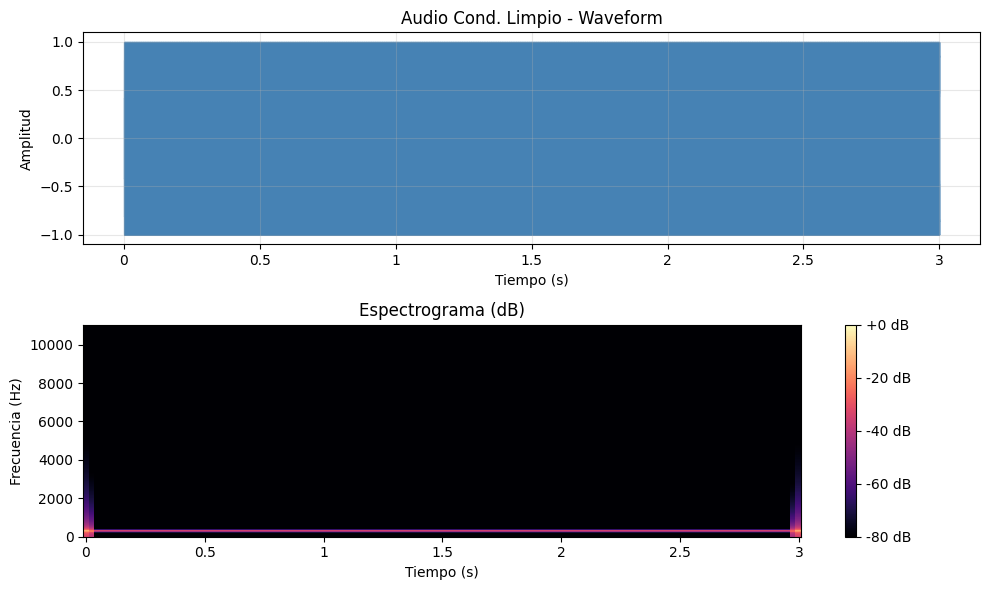

📏 Duración: 3.00 s
🔊 Amplitud: [-1.000, 1.000]
⚡ Energía RMS: 0.7071
🔄 Zero-Crossing Rate medio: 0.0269

--- Aplicando a Audio Largo (necesita recorte) ---
✅ Sample rate ya es 22050 Hz. No se remuestrea.
✅ Amplitud normalizada a [-1, +1]
✂️ Recortado a 3.0s (centrado)


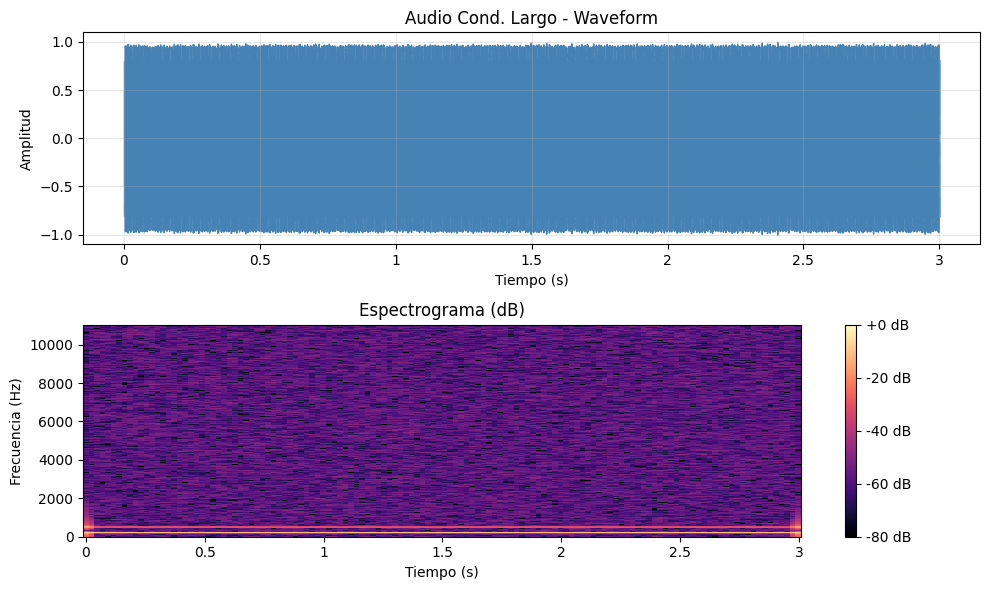

📏 Duración: 3.00 s
🔊 Amplitud: [-1.000, 0.993]
⚡ Energía RMS: 0.4893
🔄 Zero-Crossing Rate medio: 0.0476


In [3]:
# Necessary imports, if not already handled by a previous cell that is guaranteed to run
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

# Definition of generar_audio_prueba (copied from Tx5K8M3wRZv9 for self-containment)
def generar_audio_prueba(frecuencias, duracion=3.0, sr=22050, ruido=0.02):
    """
    Genera una señal de audio sintética para prácticas.
    Parámetros:
    - frecuencias: lista de frecuencias en Hz (ej. [200, 400])
    - duracion: duración en segundos
    - sr: sample rate
    - ruido: nivel de ruido blanco añadido (0.0 = limpio)
    """
    t = np.linspace(0, duracion, int(sr * duracion), endpoint=False)
    señal = np.zeros_like(t)
    # Sumar ondas senoidales
    for f in frecuencias: señal += np.sin(2 * np.pi * f * t)
    # Normalizar a [-0.8, +0.8] para dejar margen
    señal = 0.8 * señal / np.max(np.abs(señal))
    # Añadir ruido blanco opcional
    if ruido > 0: señal += ruido * np.random.randn(len(señal))
    señal = np.clip(señal, -1, 1) # Evitar saturación
    return señal, sr

# Definition of diagnosticar_audio (copied from VbozddLwSmt- for self-containment)
def diagnosticar_audio (audio, sr, titulo ="Diagnóstico"):
    """Muestra waveform y espectrograma básico para evaluación visual"""
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
    #Waveform

    librosa.display.waveshow(audio, sr=sr, ax=ax1, color='steelblue')
    ax1.set_title(f'{titulo} - Waveform')
    ax1.set_xlabel('Tiempo (s)')
    ax1.set_ylabel('Amplitud')
    ax1.grid(True, alpha=0.3)
    # Espectrograma (STFT básica)
    D = np.abs(librosa.stft(audio))
    S_db = librosa.amplitude_to_db(D, ref=np.max)
    img = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz', ax=ax2,
    cmap='magma')
    ax2.set_title('Espectrograma (dB)')
    ax2.set_xlabel('Tiempo (s)')
    ax2.set_ylabel('Frecuencia (Hz)')
    plt.colorbar(img, ax=ax2, format='%+2.0f dB')
    plt.tight_layout()
    plt.show()
    # Métricas rápidas
    print(f"📏 Duración: {len(audio)/sr:.2f} s")
    print(f"🔊 Amplitud: [{audio.min():.3f}, {audio.max():.3f}]")
    print(f"⚡ Energía RMS: {np.sqrt(np.mean(audio**2)):.4f}")
    print(f"🔄 Zero-Crossing Rate medio: {librosa.feature.zero_crossing_rate(audio).mean():.4f}")

# Re-create audio samples for the demonstration
audio_limpio, sr = generar_audio_prueba([300], ruido=0.0)
audio_ruidoso, _ = generar_audio_prueba([300], ruido=0.05)
audio_largo, _ = generar_audio_prueba([200, 500], duracion=8.0, ruido=0.01)

# 🚀 Aplicando pipeline condicional al audio limpio (3s, 22050 Hz)
print("\n--- Aplicando a Audio Limpio (ya cumple requisitos) ---")
audio_cond_limpio, sr_cond_limpio = pipeline_normalizacion_condicional(audio_limpio, sr, target_dur=3.0)
diagnosticar_audio(audio_cond_limpio, sr_cond_limpio, "Audio Cond. Limpio")

# 🚀 Aplicando pipeline condicional al audio largo (8s, 22050 Hz)
print("\n--- Aplicando a Audio Largo (necesita recorte) ---")
audio_cond_largo, sr_cond_largo = pipeline_normalizacion_condicional(audio_largo, sr, target_dur=3.0)
diagnosticar_audio(audio_cond_largo, sr_cond_largo, "Audio Cond. Largo")

### Ventajas del enfoque "inteligente" de preprocesamiento condicional:

Este enfoque tiene varias ventajas significativas, especialmente cuando se trabaja con grandes datasets de audio o en entornos de producción:

1.  **Eficiencia Computacional:**
    *   **Ahorro de Tiempo y Recursos:** Operaciones como el remuestreo (`librosa.resample`) y el ajuste de duración (`librosa.effects.trim`, `np.pad`) son costosas computacionalmente. Al evitarlas cuando no son estrictamente necesarias, se reduce el tiempo de procesamiento y el uso de CPU/RAM. Esto es crucial en datasets con miles o millones de audios.
    *   **Procesamiento más Rápido:** Los audios que ya cumplen con los requisitos deseados pasan por el pipeline de forma casi instantánea, acelerando el proceso general.

2.  **Preservación de la Calidad del Audio:**
    *   **Minimización de Pérdidas y Artefactos:** Cada operación de procesamiento puede introducir pequeñas pérdidas de información o artefactos (ej. el remuestreo puede causar aliasing o suavizado). Al evitar el procesamiento innecesario, se mantiene la calidad original del audio cuando ya es adecuada, preservando su fidelidad.
    *   **Menos Distorsión:** Se asegura que los audios que ya están "bien" no sean modificados de manera contraproducente, manteniendo su integridad acústica.

3.  **Flexibilidad y Robustez:**
    *   **Adaptabilidad a Datos Heterogéneos:** Este pipeline puede manejar una mayor variedad de audios de entrada sin fallar o producir resultados subóptimos, ya que se adapta a las características de cada audio individualmente. Esto es muy útil en datasets del mundo real que rara vez son perfectamente uniformes.
    *   **Menos Errores Potenciales:** Al no aplicar operaciones cuando no son requeridas, se reduce la probabilidad de introducir errores o transformaciones indeseadas.

4.  **Claridad y Mantenibilidad del Código:**
    *   **Lógica Explícita:** La lógica condicional hace que sea claro para otros desarrolladores (o para uno mismo en el futuro) por qué se realizan o no ciertas operaciones, mejorando la comprensión del flujo de preprocesamiento.
    *   **Depuración Simplificada:** Si surge un problema, es más fácil identificar qué parte del pipeline se ejecutó (o no se ejecutó) para un audio específico, facilitando la depuración.

5.  **Optimización del Dataset Final:**
    *   Se garantiza que todos los audios en el dataset final cumplan con los requisitos del modelo, pero de la manera más "suave" y menos invasiva posible, sin sobreprocesamiento.

En resumen, el preprocesamiento condicional es una práctica recomendada en el procesamiento de señales de audio que busca un equilibrio entre la uniformidad de los datos requerida por los modelos y la eficiencia/calidad de las operaciones, aplicando solo las transformaciones que son estrictamente necesarias.